# **Amazon Product Recommendation System**

# Problem Understanding

Build and evaluate a hybrid recommendation engine (content-based + collaborative filtering) for an e-commerce platform using product metadata and
user behavior data.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Upload file
from google.colab import files
uploaded = files.upload()

Saving amazon.csv to amazon (2).csv


In [ ]:
# Read data into df
df = pd.read_csv('amazon.csv')
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


# Data Cleaning and Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [ ]:
# Convert price columns
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

In [ ]:
# Convert discount percentage
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

In [ ]:
# Check unique elements in rating
df['rating'].unique()

array(['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [ ]:
# Remove rows where rating is '|'
df = df[df['rating'] != '|']

In [ ]:
# Convert rating
df['rating'] = df['rating'].astype(float)

In [ ]:
# Convert rating_count
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

In [ ]:
# Drop rows where rating_count values are null
df = df.dropna(subset=['rating_count'])

In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [ ]:
len(df)

1462

In [ ]:
# Unique counts
num_users = df['user_id'].nunique()
num_products = df['product_id'].nunique()
num_reviews = df['review_id'].nunique()

print(f"Users: {num_users}")
print(f"Products: {num_products}")
print(f"Reviews: {num_reviews}")

Users: 1191
Products: 1348
Reviews: 1191


In [ ]:
# Extract main category (level 1)
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])

top_categories = df.groupby('main_category')['product_id'].nunique() \
                   .sort_values(ascending=False).head(5)

print(top_categories)

main_category
Electronics              490
Home&Kitchen             447
Computers&Accessories    373
OfficeProducts            31
MusicalInstruments         2
Name: product_id, dtype: int64


In [ ]:
# Price Range & Discount Insights
print("Price Range:")
print(df[['discounted_price', 'actual_price']].describe())

print("\nDiscount Insights:")
print(df['discount_percentage'].describe())

Price Range:
       discounted_price   actual_price
count       1462.000000    1462.000000
mean        3129.981826    5453.087743
std         6950.548042   10884.467444
min           39.000000      39.000000
25%          325.000000     800.000000
50%          799.000000    1670.000000
75%         1999.000000    4321.250000
max        77990.000000  139900.000000

Discount Insights:
count    1462.000000
mean       47.672367
std        21.613905
min         0.000000
25%        32.000000
50%        50.000000
75%        63.000000
max        94.000000
Name: discount_percentage, dtype: float64


# EDA

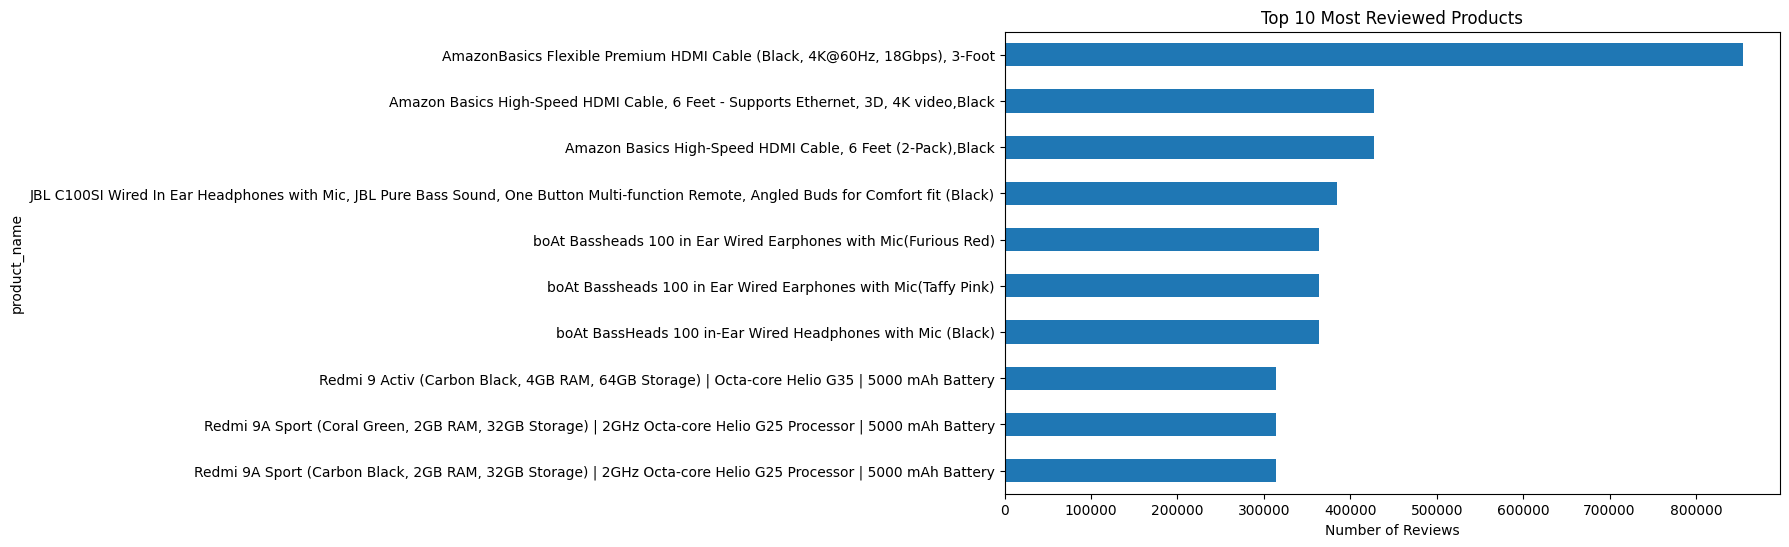

In [ ]:
# Most Reviewed Products
top_reviewed = df.groupby('product_name')['rating_count'].sum() \
                 .sort_values(ascending=False).head(10)

top_reviewed.plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.show()

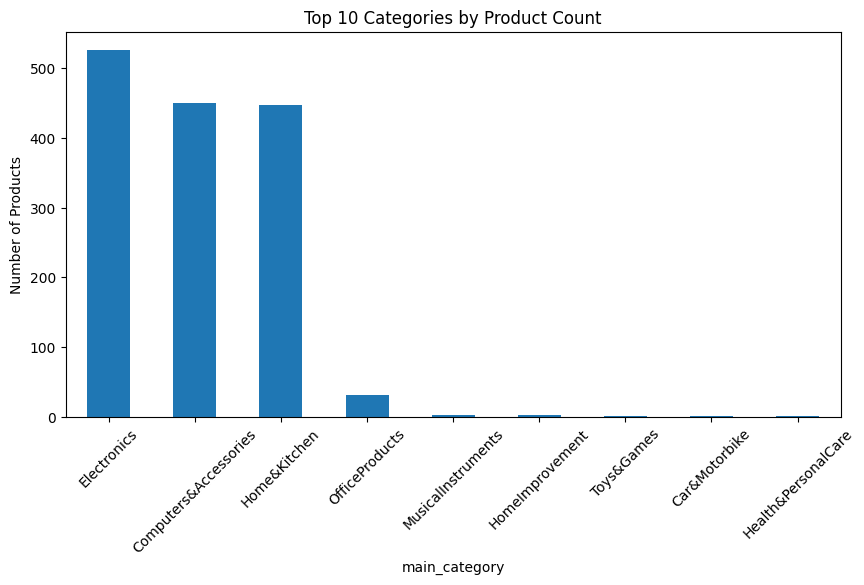

In [ ]:
# Top 10 Categories by Number of Products
top_categories = df['main_category'].value_counts().head(10)

top_categories.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Categories by Product Count")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

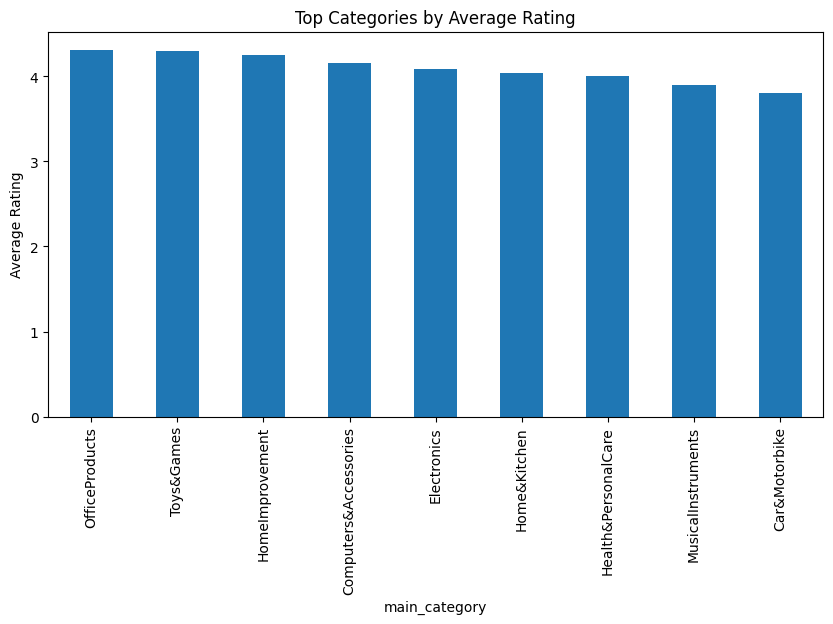

In [ ]:
# Average Rating per Category
avg_rating_cat = df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

avg_rating_cat.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Categories by Average Rating")
plt.ylabel("Average Rating")
plt.show()

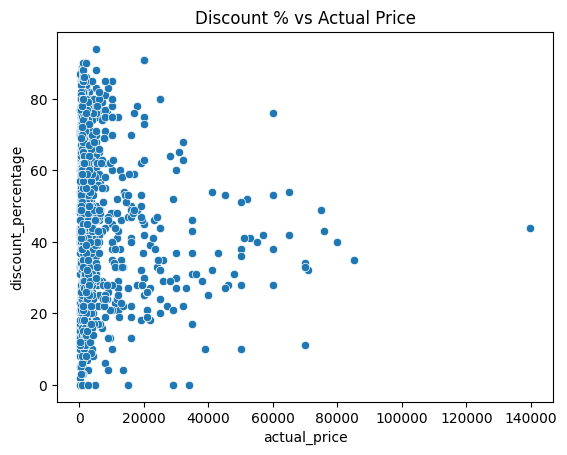

                     actual_price  discount_percentage
actual_price             1.000000            -0.117855
discount_percentage     -0.117855             1.000000


In [ ]:
# Discount vs Actual Price Correlation
import seaborn as sns

sns.scatterplot(
    x=df['actual_price'],
    y=df['discount_percentage']
)
plt.title("Discount % vs Actual Price")
plt.show()

# Correlation
print(df[['actual_price', 'discount_percentage']].corr())

In [ ]:
# High Rating BUT Low Review Count
high_rating_low_reviews = df[
    (df['rating'] >= 4.5) & (df['rating_count'] < 50)
]

high_rating_low_reviews[['product_name','rating','rating_count']].head(10)

,product_name,rating,rating_count
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0,5.0
299,WANBO X1 Pro (Upgraded) | Native 1080P Full HD...,4.5,7.0
547,Noise_Colorfit Smart Watch Charger 2 Pin USB F...,4.5,38.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0,23.0
1158,!!1000 Watt/2000-Watt Room Heater!! Fan Heater...,4.5,11.0
1164,Homeistic Applience™ Instant Electric Water He...,4.5,19.0
1201,"Oratech Coffee Frother electric, milk frother ...",4.8,28.0
1293,Melbon VM-905 2000-Watt Room Heater (ISI Certi...,4.6,9.0


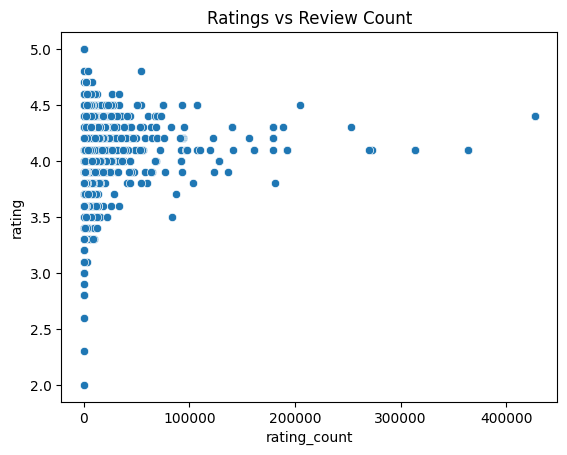

                rating  rating_count
rating        1.000000      0.102235
rating_count  0.102235      1.000000


In [ ]:
# Are Highly Rated Products Also Heavily Reviewed?
sns.scatterplot(
    x=df['rating_count'],
    y=df['rating']
)
plt.title("Ratings vs Review Count")
plt.show()

# Correlation
print(df[['rating','rating_count']].corr())

**Insights**

Key Findings:
1) Discount strategy is weakly correlated with price, indicating inconsistent pricing tactics across categories.
2) Product ratings have weak correlation with review count, meaning popularity does not guarantee quality.
3) High-rated products with low reviews exist, representing untapped opportunities for promotion.

Business Recommendations:
1) Optimize discount strategies based on price sensitivity.
2) Promote hidden high-quality products to increase discovery.
3) Use weighted ranking (rating + review count) instead of raw ratings.


# Preprocessing after EDA

In [ ]:
# Drop unncessary columns
df = df.drop(columns=['user_name', 'review_id', 'review_title', 'img_link', 'product_link'])

In [ ]:
# Split columns into lists
cols_to_split = ['user_id']

df[cols_to_split] = df[cols_to_split].apply(lambda x: x.str.split(','))

In [ ]:
# Explode user_id column
df = df.explode(cols_to_split, ignore_index=True)

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,review_content,main_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35Q,Looks durable Charging is fine tooNo complains...,Computers&Accessories
1,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AHMY5CWJMMK5BJRBBSNLYT3ONILA,Looks durable Charging is fine tooNo complains...,Computers&Accessories
2,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AHCTC6ULH4XB6YHDY6PCH2R772LQ,Looks durable Charging is fine tooNo complains...,Computers&Accessories
3,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AGYHHIERNXKA6P5T7CZLXKVPT7IQ,Looks durable Charging is fine tooNo complains...,Computers&Accessories
4,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q,Looks durable Charging is fine tooNo complains...,Computers&Accessories


In [ ]:
len(df)

11493

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11493 entries, 0 to 11492
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           11493 non-null  object 
 1   product_name         11493 non-null  object 
 2   category             11493 non-null  object 
 3   discounted_price     11493 non-null  float64
 4   actual_price         11493 non-null  float64
 5   discount_percentage  11493 non-null  float64
 6   rating               11493 non-null  float64
 7   rating_count         11493 non-null  float64
 8   about_product        11493 non-null  object 
 9   user_id              11493 non-null  object 
 10  review_content       11493 non-null  object 
 11  main_category        11493 non-null  object 
dtypes: float64(5), object(7)
memory usage: 1.1+ MB


In [ ]:
# Change the case to lower
df['about_product'] = df['about_product'].str.lower()
df['review_content'] = df['review_content'].str.lower()
df['product_name'] = df['product_name'].str.lower()
df['category'] = df['category'].str.lower()

In [ ]:
# Number of duplicate interactions
df.duplicated(subset=['product_id', 'user_id']).sum()

np.int64(899)

In [ ]:
# Find those duplicate pairs
duplicate_pairs = df.groupby(['user_id', 'product_id']).size()
duplicate_pairs = duplicate_pairs[duplicate_pairs > 1].reset_index()[['user_id', 'product_id']]
duplicate_pairs

,user_id,product_id
0,AE2E632GMYL5U2ESNXOX5UT5D34A,B094JNXNPV
1,AE2OFVZSIE6KSBAPG6GMKCER35LA,B07DJLFMPS
2,AE33MAZWYRVAAICGNACZAIWACK7Q,B07RD611Z8
3,AE3D5CJ2GDUP5SQ3AAYMVAGDTX7A,B07KSMBL2H
4,AE3MQNNHHLUHXURL5S7IAR7JTGNQ,B08CF3B7N1
...,...,...
718,AHYUZ2BLKNN6UJLFYWCXCEFZTOVQ,B07P681N66
719,AHZNSNBVKQR4OGJAQHE4DCDA4YHA,B0B3MWYCHQ
720,AHZRUY7MR4SVM3HFJ2SZDGHZJ56A,B0BDRVFDKP
721,AHZWJCVEIEI76H2VGMUSN5D735IQ,B09W5XR9RT


In [ ]:
# Merge it with the original df
dup_df = df.merge(duplicate_pairs, on=['user_id', 'product_id'], how='inner')

In [ ]:
# Check if ratings are same or different
dup_df.groupby(['user_id', 'product_id'])['rating'].nunique().value_counts()

,count
rating,
1,723


In [ ]:
# Check if review content is same or different
dup_df.groupby(['user_id', 'product_id'])['review_content'].nunique().value_counts()

,count
review_content,
1,586
2,129
3,8


In [ ]:
# Check if review content is same or different
dup_df.groupby(['user_id', 'product_id'])['rating_count'].nunique().value_counts()

,count
rating_count,
1,482
2,241


In [ ]:
# Combine review content
df = df.groupby(['user_id', 'product_id'], as_index=False).agg({
    'rating': 'first',
    'review_content': ' '.join,
    'product_name': 'first',
    'category': 'first',
    'about_product': 'first',
    'discounted_price': 'first',
    'actual_price': 'first',
    'discount_percentage': 'first',
    'rating_count': 'max'
})

# TF-IDF + Content based filtering

In [ ]:
# df = df.reset_index(drop=True)

In [ ]:
# Weighted rating
C = df['rating'].mean()
m = df['rating_count'].quantile(0.75)

df['weighted_rating'] = (
    (df['rating_count'] / (df['rating_count'] + m)) * df['rating'] +
    (m / (df['rating_count'] + m)) * C
)

Weighted rating adjusts product ratings by accounting for the number of reviews, ensuring that highly rated products with few reviews do not unfairly outrank consistently rated popular products.

Weighted rating pulls small-sample ratings toward the average and keeps large-sample ratings close to their original value.

In [ ]:
# Simulate bad rating
df.loc[df['product_id'] == 'B0B31FR4Y2', 'rating'] = 2.0

# Simulate no reviews
df.loc[df['product_id'] == 'B0B31FR4Y2', 'review_content'] = ""

In [ ]:
# Make products UNIQUE
content_df = df.drop_duplicates(subset='product_id').reset_index(drop=True)

In [ ]:
# Combine text for content-based filtering
content_df['combined_text'] = (
    content_df['product_name'] + " " +
    content_df['category'].str.split("|").str[0] + " " +
    content_df['about_product']
)

In [ ]:
# Convert Text → Numbers (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(content_df['combined_text'])

In [ ]:
# Numerical features
from sklearn.preprocessing import MinMaxScaler

num_features = content_df[['discounted_price', 'weighted_rating', 'discount_percentage']]

scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(num_features)

In [ ]:
# Combine text and numbers
from scipy.sparse import hstack

final_features = hstack([
    tfidf_matrix * 0.8,   # text importance
    num_scaled * 0.2      # numeric importance
])

In [ ]:
# Compute Similarity
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(final_features)

content_similarity_df = pd.DataFrame(
    cosine_sim,
    index=content_df['product_id'],
    columns=content_df['product_id']
)

In [ ]:
# Create Product Index Mapping
indices = pd.Series(content_df.index, index=content_df['product_id']).drop_duplicates()

In [ ]:
# Recommendation function
def recommend_products_CB(product_id, top_n=5):

    if product_id not in indices:
        return "Product not found"

    idx = indices[product_id]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # remove itself
    sim_scores = sim_scores[1:]

    selected = []
    seen_names = set()
    seen_categories = set()

    for i, score in sim_scores:
        if df.iloc[i]['product_id'] == product_id:
          continue
        name = df.iloc[i]['product_name']
        category = df.iloc[i]['category']
        rating = df.iloc[i]['weighted_rating']

        if rating < 3.5:
            continue  # skip bad products

        # avoid repetition + ensure diversity
        if name not in seen_names and category not in seen_categories:
            selected.append((i, score))
            seen_names.add(name)
            seen_categories.add(category)

        if len(selected) >= top_n:
            break

    product_indices = [i[0] for i in selected]

    return df.iloc[product_indices][[
        'product_id',
        'product_name',
        'category',
        'discounted_price',
        'rating'
    ]]

In [ ]:
recommend_products_CB('B0B31FR4Y2', 10)

,product_id,product_name,category,discounted_price,rating
51,B09ND94ZRG,boult audio airbass propods x tws bluetooth tr...,"electronics|headphones,earbuds&accessories|hea...",1099.0,3.5
644,B08H6CZSHT,philips easyspeed plus steam iron gc2145/20-22...,"home&kitchen|kitchen&homeappliances|vacuum,cle...",2903.0,4.3
646,B07J2NGB69,"lenovo 400 wireless mouse, 1200dpi optical sen...",computers&accessories|accessories&peripherals|...,629.0,4.4
1295,B07WMS7TWB,pigeon by stovekraft amaze plus electric kettl...,home&kitchen|kitchen&homeappliances|smallkitch...,649.0,3.9
296,B07NC12T2R,boat stone 650 10w bluetooth speaker with upto...,electronics|homeaudio|speakers|bluetoothspeakers,1799.0,4.2
532,B08P9RYPLR,flix (beetel) usb to iphone lightning textured...,computers&accessories|accessories&peripherals|...,129.0,4.0
866,B0763K5HLQ,instacuppa milk frother for coffee - handheld ...,"home&kitchen|kitchen&homeappliances|coffee,tea...",1099.0,4.1
233,B09SFRNKSR,fabware lint remover for clothes - sticky lint...,"home&kitchen|kitchen&homeappliances|vacuum,cle...",298.0,4.4
64,B002SZEOLG,tp-link nano usb wifi dongle 150mbps high gain...,computers&accessories|networkingdevices|networ...,749.0,4.2
1096,B09PLD9TCD,kodak 126 cm (50 inches) bezel-less design ser...,"electronics|hometheater,tv&video|televisions|s...",26999.0,4.2


# Collaborative filtering

In [ ]:
# Build the Interaction Matrix
user_item_matrix = df.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating'
)

In [ ]:
# Fill missing values
user_item_matrix = user_item_matrix.fillna(0)

In [ ]:
# Find number of unique users and products
n_users = df['user_id'].nunique()
n_products = df['product_id'].nunique()

print("Users:", n_users)
print("Products:", n_products)

Users: 9040
Products: 1348


Recommended:  Item-Based Collaborative Filtering

We have more users than products.
Users have few interactions.
Products are more stable.

So we compute product–product similarity

In [ ]:
# Compute Item Similarity
item_similarity = cosine_similarity(user_item_matrix.T)

In [ ]:
# Convert to DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

In [ ]:
# Recommendation Function
def recommend_products_CF(product_id, top_n=5):
    similar_scores = item_similarity_df[product_id].sort_values(ascending=False)
    return similar_scores.iloc[1:top_n+1]

In [ ]:
recommend_products_CF("B08TTRVWKY")

,B08TTRVWKY
product_id,
B09GB5B4BK,0.0
B09G5TSGXV,0.0
B09G2VTHQM,0.0
B09FZ89DK6,0.0
B09FPP3R1D,0.0


Our dataset is too sparse for memory-based CF (user/item).
SVD works because it learns latent structure instead of relying on overlaps.

In [ ]:
from sklearn.decomposition import TruncatedSVD

# SVD
svd = TruncatedSVD(n_components=50)
item_features = svd.fit_transform(user_item_matrix.T)

# Similarity
item_similarity = cosine_similarity(item_features)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

In [ ]:
recommend_products_CF("B08TTRVWKY")

,B08TTRVWKY
product_id,
B07ZR4S1G4,0.862161
B0BNDRK886,0.842571
B00LXTFMRS,0.750504
B098LCVYPW,0.748952
B07HZ2QCGR,0.742330


In [ ]:
# Recommendation function for a user
def recommend_for_user_CF(user_id, top_n=5):
    user_data = df[df['user_id'] == user_id]

    scores = {}

    for _, row in user_data.iterrows():
        product = row['product_id']
        rating = row['rating']

        similar_products = item_similarity_df[product]

        for sim_product, sim_score in similar_products.items():
            # Skip already interacted products
            if sim_product in user_data['product_id'].values:
                continue

            # Weighted score
            scores[sim_product] = scores.get(sim_product, 0) + sim_score * rating

    # Normalize scores
    for product in scores:
        scores[product] /= len(user_data)

    # Sort and return top N
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return recommended[:top_n]

In [ ]:
# History of a random user
user_data = df[df['user_id'] == 'AE22E2AXODSPNK3EBIHNGYS5LOSA']
user_data.head()

,user_id,product_id,rating,review_content,product_name,category,about_product,discounted_price,actual_price,discount_percentage,rating_count,weighted_rating
0,AE22E2AXODSPNK3EBIHNGYS5LOSA,B0B31FR4Y2,2.0,,"boult audio omega with 30db anc+ enc, 32h play...","electronics|headphones,earbuds&accessories|hea...",note : if the size of the earbud tips does not...,1999.0,9999.0,80.0,1986.0,4.049722


In [ ]:
# Recommendation df for CF
top_items = recommend_for_user_CF('AE22E2AXODSPNK3EBIHNGYS5LOSA')

# Convert to DataFrame
rec_df = pd.DataFrame(top_items, columns=['product_id', 'score'])

# Merge with product details
rec_df = rec_df.merge(
    content_df[['product_id', 'product_name', 'category', 'discounted_price', 'rating']],
    on='product_id',
    how='left'
)

rec_df

,product_id,score,product_name,category,discounted_price,rating
0,B07CWDX49D,1.575491,amazonbasics double braided nylon usb type-c t...,computers&accessories|accessories&peripherals|...,649.0,4.3
1,B07CWNJLPC,1.575491,amazonbasics double braided nylon usb type-c t...,computers&accessories|accessories&peripherals|...,499.0,4.3
2,B0B8ZKWGKD,1.400807,zorbes® wall adapter holder for alexa echo dot...,"electronics|hometheater,tv&video|accessories|t...",893.0,4.3
3,B097R2V1W8,1.321299,bajaj splendora 3 litre 3kw iwh instant water ...,"home&kitchen|heating,cooling&airquality|waterh...",2599.0,4.1
4,B07NCKMXVZ,1.294894,"stylehouse lint remover for woolen clothes, el...","home&kitchen|kitchen&homeappliances|vacuum,cle...",455.0,4.1


In [ ]:
user_product_counts = df.groupby('user_id')['product_id'].nunique()

print(user_product_counts.describe())

count    9040.000000
mean        1.171903
std         0.638485
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         9.000000
Name: product_id, dtype: float64


The recommendations were evaluated by comparing them with the user’s historical interactions. It was observed that the system suggests products that are similar to previously interacted items, indicating that it effectively captures user preferences. For example, users who interacted with a particular category of products were recommended items from related categories, demonstrating meaningful personalization.

However, collaborative filtering faces several challenges. The dataset is highly sparse, which makes it difficult to compute reliable similarities using traditional methods. Although techniques like SVD help mitigate this issue, cold start remains a problem for new users and products with no interaction history. Additionally, collaborative filtering tends to favor popular items, leading to popularity bias, and lacks the ability to incorporate contextual or content-based information. These limitations suggest that a hybrid approach combining collaborative and content-based methods would further improve recommendation quality.

# Content + Collaborative filtering

In [ ]:
def hybrid_recommend(user_id, top_n=5, alpha=0.6):
    user_data = df[df['user_id'] == user_id]

    scores = {}

    for _, row in user_data.iterrows():
        product = row['product_id']
        rating = row['rating']

        # CF similarity
        if product in item_similarity_df.columns:
            cf_sim = item_similarity_df[product]
        else:
            cf_sim = {}

        # Content similarity
        if product in content_similarity_df.columns:
            content_sim = content_similarity_df[product]
        else:
            content_sim = {}

        # Combine both
        for sim_product in set(cf_sim.keys()).union(content_sim.keys()):

            if sim_product in user_data['product_id'].values:
                continue

            cf_score = cf_sim.get(sim_product, 0)
            content_score = content_sim.get(sim_product, 0)

            final_score = alpha * cf_score + (1 - alpha) * content_score

            scores[sim_product] = scores.get(sim_product, 0) + final_score * rating

    # Normalize
    for product in scores:
        scores[product] /= len(user_data)

    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return recommended[:top_n]

In [ ]:
# History of a random user
user_data = df[df['user_id'] == 'AE22E2AXODSPNK3EBIHNGYS5LOSA']
user_data.head()

,user_id,product_id,rating,review_content,product_name,category,about_product,discounted_price,actual_price,discount_percentage,rating_count,weighted_rating
0,AE22E2AXODSPNK3EBIHNGYS5LOSA,B0B31FR4Y2,2.0,,"boult audio omega with 30db anc+ enc, 32h play...","electronics|headphones,earbuds&accessories|hea...",note : if the size of the earbud tips does not...,1999.0,9999.0,80.0,1986.0,4.049722


In [ ]:
# Recommendation df for Hybrid
top_items = hybrid_recommend('AE22E2AXODSPNK3EBIHNGYS5LOSA')

# Convert to DataFrame
rec_df = pd.DataFrame(top_items, columns=['product_id', 'score'])

# Merge with product details
rec_df = rec_df.merge(
    content_df[['product_id', 'product_name', 'category', 'discounted_price', 'rating']],
    on='product_id',
    how='left'
)

rec_df

,product_id,score,product_name,category,discounted_price,rating
0,B08FN6WGDQ,1.148346,samsung galaxy buds live bluetooth truly wirel...,"electronics|headphones,earbuds&accessories|hea...",4790.0,4.0
1,B07CWNJLPC,1.005967,amazonbasics double braided nylon usb type-c t...,computers&accessories|accessories&peripherals|...,499.0,4.3
2,B07CWDX49D,1.004511,amazonbasics double braided nylon usb type-c t...,computers&accessories|accessories&peripherals|...,649.0,4.3
3,B0B8ZKWGKD,0.864477,zorbes® wall adapter holder for alexa echo dot...,"electronics|hometheater,tv&video|accessories|t...",893.0,4.3
4,B097R2V1W8,0.827059,bajaj splendora 3 litre 3kw iwh instant water ...,"home&kitchen|heating,cooling&airquality|waterh...",2599.0,4.1


In [ ]:
# Test CF and Content for a single product
product = "B097R3XH9R"

cf_top = item_similarity_df[product].sort_values(ascending=False)[1:10]
content_top = content_similarity_df[product].sort_values(ascending=False)[1:10]

print("CF:", list(cf_top.index))
print("Content:", list(content_top.index))

CF: ['B00N1U7JXM', 'B00P93X6EK', 'B0B54Y2SNX', 'B09Z6WH2N1', 'B0B8ZWNR5T', 'B094YFFSMY', 'B09YL9SN9B', 'B00J4YG0PC', 'B0BFBNXS94']
Content: ['B097R4D42G', 'B097R45BH8', 'B09N3BFP4M', 'B07TC9F7PN', 'B097R2V1W8', 'B01892MIPA', 'B077BTLQ67', 'B08WRKSF9D', 'B08YRMBK9R']


# Business Strategy & Deployment

**Which Model Works Best for New Users?**

Content-based filtering works best for new users as it does not rely on historical interaction data. Instead, it recommends products based on item features such as category and description, making it effective in cold start scenarios.

**Which Model Works Best for Returning Users?**

For returning users, collaborative filtering (especially SVD-based) is more effective as it leverages past user interactions to generate personalized recommendations. A hybrid approach further enhances performance by combining behavioral patterns with content-based signals.

**How to Recommend Products with No Ratings?**

Products with no ratings can be recommended using content-based filtering by leveraging product attributes such as descriptions and categories. Additionally, popularity-based methods and hybrid strategies can be used to ensure visibility for new items.

**How to Deploy This System in Production?**

The system can be deployed using a modular architecture with offline and online components. The recommendation models (SVD and TF-IDF) are trained offline and stored in a database. A REST API built using FastAPI or Flask serves recommendations in real-time. The system can be deployed using Docker and scaled using Kubernetes on cloud platforms such as AWS. Caching mechanisms like Redis can be used to improve response time.

**KPIs Amazon Should Track**

Key performance indicators for evaluating the recommendation system include click-through rate (CTR), conversion rate, and revenue per user, which measure the effectiveness of recommendations in driving user actions. Additionally, metrics such as average order value, repeat purchase rate, and user engagement help assess long-term impact. Coverage and diversity metrics are also important to ensure that a wide range of products is recommended and that users are exposed to novel items.